In [6]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data

--2026-04-26 12:16:47--  https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘processed.cleveland.data’

processed.cleveland     [ <=>                ]  18.03K  --.-KB/s    in 0.06s   

2026-04-26 12:16:47 (296 KB/s) - ‘processed.cleveland.data’ saved [18461]



In [7]:
import pandas as pd

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv('processed.cleveland.data', names=columns)

print("Shape:", df.shape)
print(df.head())

Shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


# PRE-2: Missing Values Detection & Cleaning

In [8]:
import numpy as np

df.replace("?", np.nan, inplace=True)

In [9]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [10]:
cols_to_fix = ['ca', 'thal']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col])

In [11]:
before = df.shape[0]

df.dropna(inplace=True)

after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 303
Rows after: 297
Rows removed: 6


# PRE-3: Class Distribution Analysis

In [12]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [13]:
counts = df['target'].value_counts()
percent = df['target'].value_counts(normalize=True) * 100

print("Class Counts:\n", counts)
print("\nClass Percentages:\n", percent)

Class Counts:
 target
0    160
1    137
Name: count, dtype: int64

Class Percentages:
 target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


# Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (237, 13)
Test set shape: (60, 13)


# Encoding + Standardization

In [15]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

In [16]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

In [17]:
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_encoded[continuous_cols] = scaler.fit_transform(
    X_train_encoded[continuous_cols]
)

X_test_encoded[continuous_cols] = scaler.transform(
    X_test_encoded[continuous_cols]
)

# PART A1 — K-Means Clustering

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = X_train_encoded.values  # use ONLY training features for unsupervised learning

k_values = range(2, 9)
wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))

print("WCSS:", wcss)
print("Silhouette:", sil_scores)

WCSS: [1723.1853440195086, 1573.0250532402804, 1465.372496172431, 1383.496077708347, 1335.1795438795173, 1274.88709438776, 1240.7031184141135]
Silhouette: [np.float64(0.166794349010712), np.float64(0.12454425309629531), np.float64(0.11719572365155125), np.float64(0.12320721477422653), np.float64(0.10674452769098718), np.float64(0.10163366639558975), np.float64(0.09847797217686416)]


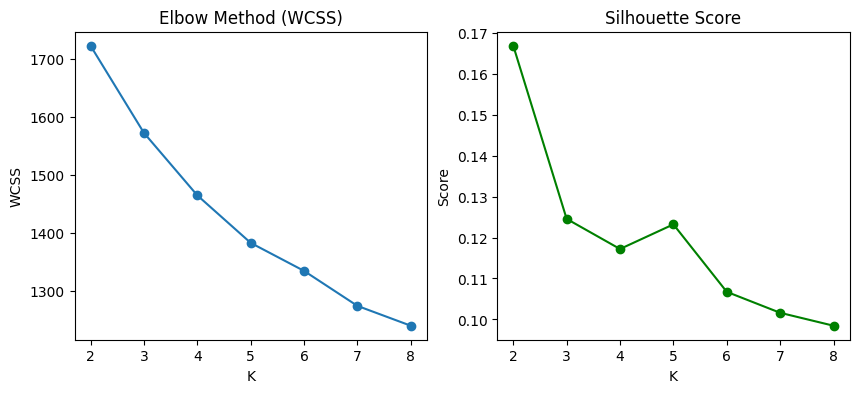

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method (WCSS)")
plt.xlabel("K")
plt.ylabel("WCSS")

plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, marker='o', color='green')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")

plt.show()

In [21]:
best_k = 2  # change after observing plots

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

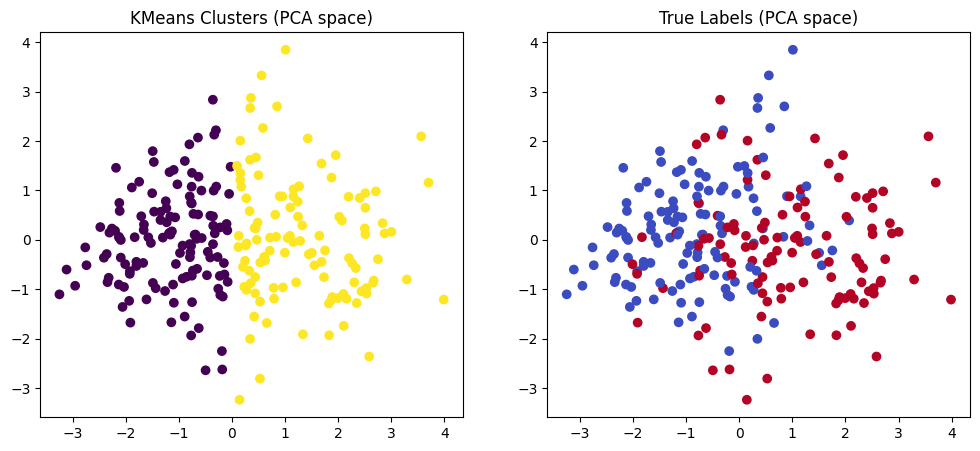

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis')
plt.title("KMeans Clusters (PCA space)")

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='coolwarm')
plt.title("True Labels (PCA space)")

plt.show()

In [23]:
import pandas as pd

train_df = pd.DataFrame(X_train_encoded.copy())
train_df['cluster'] = cluster_labels
train_df['target'] = y_train.values

summary = train_df.groupby('cluster').agg({
    'cluster': 'count',
    'target': 'mean',
    'thalach': 'mean',
    'oldpeak': 'mean'
})

summary.rename(columns={'cluster':'size', 'target':'disease_rate'}, inplace=True)

print(summary)

         size  disease_rate   thalach   oldpeak
cluster                                        
0         126      0.222222  0.582243 -0.471038
1         111      0.729730 -0.660924  0.534692


In [24]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y_train, cluster_labels)
print("ARI Score:", ari)

ARI Score: 0.25752735022070034


# PART A2 — Hierarchical Clustering

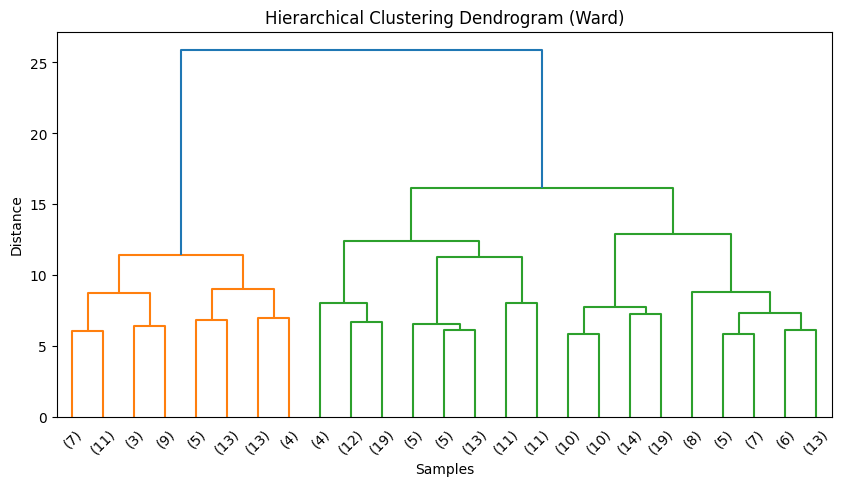

In [25]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

dendrogram = sch.dendrogram(
    sch.linkage(X, method='ward'),
    truncate_mode='lastp',
    p=25
)

plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [26]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = hc.fit_predict(X)

In [27]:
import pandas as pd

hc_df = pd.DataFrame(X_train_encoded.copy())
hc_df['cluster'] = hc_labels
hc_df['target'] = y_train.values

print(pd.crosstab(hc_df['cluster'], hc_df['target']))

target     0   1
cluster         
0        120  52
1          8  57


In [28]:
summary_hc = hc_df.groupby('cluster').agg({
    'target': 'mean',
    'thalach': 'mean',
    'oldpeak': 'mean'
})

print(summary_hc)

           target   thalach   oldpeak
cluster                              
0        0.302326  0.349055 -0.358071
1        0.876923 -0.923654  0.947512


In [29]:
from sklearn.metrics import adjusted_rand_score

ari_kmeans_hc = adjusted_rand_score(cluster_labels, hc_labels)
print("ARI (KMeans vs Hierarchical):", ari_kmeans_hc)

ARI (KMeans vs Hierarchical): 0.3716926158304224


# PART A3 — Dimensionality Reduction

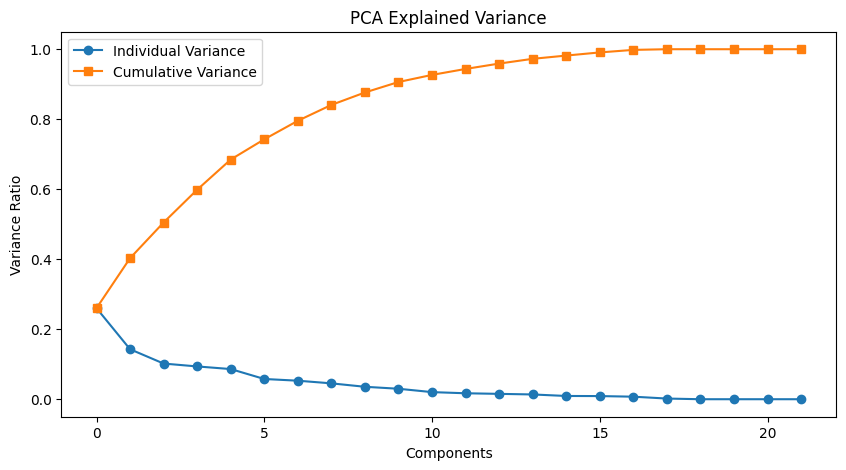

In [30]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10,5))

plt.plot(explained_var, marker='o', label='Individual Variance')
plt.plot(cumulative_var, marker='s', label='Cumulative Variance')

plt.title("PCA Explained Variance")
plt.xlabel("Components")
plt.ylabel("Variance Ratio")
plt.legend()
plt.show()

In [31]:
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print("Components needed for 90% variance:", n_components_90)

Components needed for 90% variance: 10


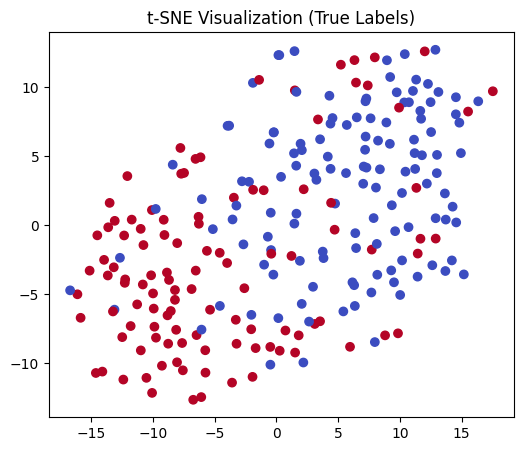

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train, cmap='coolwarm')
plt.title("t-SNE Visualization (True Labels)")
plt.show()

# PART B1 — Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

rf = RandomForestClassifier(random_state=42, oob_score=True)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_encoded, y_train)

print("Best Params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best Params: {'max_depth': 5, 'n_estimators': 200}
Best CV F1: 0.7889694108010482


In [34]:
best_rf = grid.best_estimator_
best_rf.fit(X_train_encoded, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, oob_score=True,
                       random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

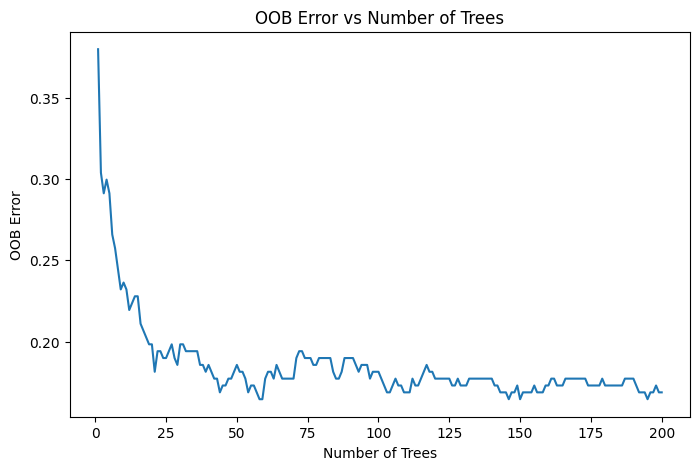

In [35]:
oob_errors = []
estimators_range = range(1, 201)

for i in estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=i,
        max_depth=best_rf.max_depth,
        random_state=42,
        oob_score=True,
        bootstrap=True
    )
    rf_temp.fit(X_train_encoded, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(estimators_range, oob_errors)
plt.title("OOB Error vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.show()

In [36]:
import pandas as pd
import numpy as np

importances = best_rf.feature_importances_
features = X_train_encoded.columns

feat_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_df.head(10))

     feature  importance
19  thal_3.0    0.108392
12    cp_4.0    0.108092
8         ca    0.100131
7    oldpeak    0.099558
21  thal_7.0    0.098896
5    thalach    0.091009
0        age    0.059145
2   trestbps    0.056264
3       chol    0.053180
6      exang    0.042023


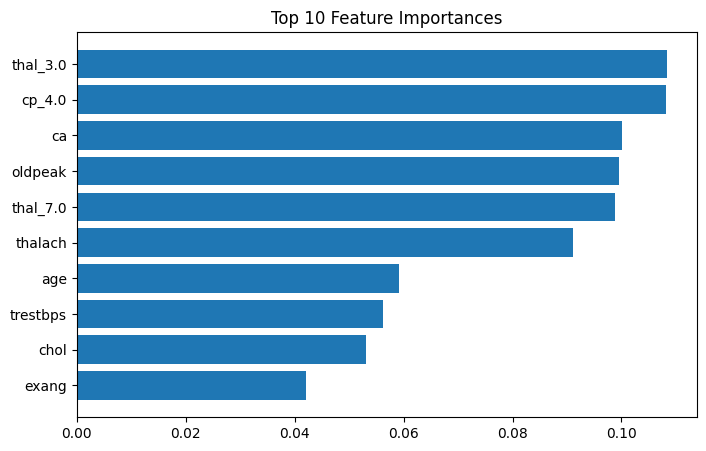

In [37]:
plt.figure(figsize=(8,5))
plt.barh(feat_df['feature'][:10][::-1], feat_df['importance'][:10][::-1])
plt.title("Top 10 Feature Importances")
plt.show()

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_rf.predict(X_test_encoded)
y_prob = best_rf.predict_proba(X_test_encoded)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60

AUC: 0.9386160714285714
Confusion Matrix:
 [[28  4]
 [ 7 21]]


# PART B2 — Gradient Boosting

In [39]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [40]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

xgb = XGBClassifier(
    n_estimators=200,
    eval_metric='logloss',
    random_state=42
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_encoded, y_train)

print("Best Params:", grid_xgb.best_params_)
print("Best CV F1:", grid_xgb.best_score_)

Best Params: {'learning_rate': 0.3, 'max_depth': 5}
Best CV F1: 0.7822695035460991


In [41]:
best_xgb = grid_xgb.best_estimator_

best_xgb.fit(
    X_train_encoded, y_train,
    eval_set=[(X_test_encoded, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

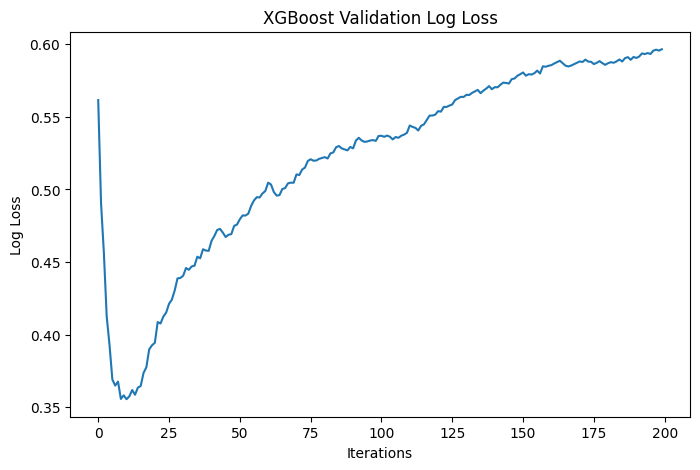

In [42]:
results = best_xgb.evals_result()

plt.figure(figsize=(8,5))
plt.plot(results['validation_0']['logloss'])
plt.title("XGBoost Validation Log Loss")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.show()

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_xgb.predict(X_test_encoded)
y_prob = best_xgb.predict_proba(X_test_encoded)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60

AUC: 0.9029017857142857
Confusion Matrix:
 [[29  3]
 [ 5 23]]


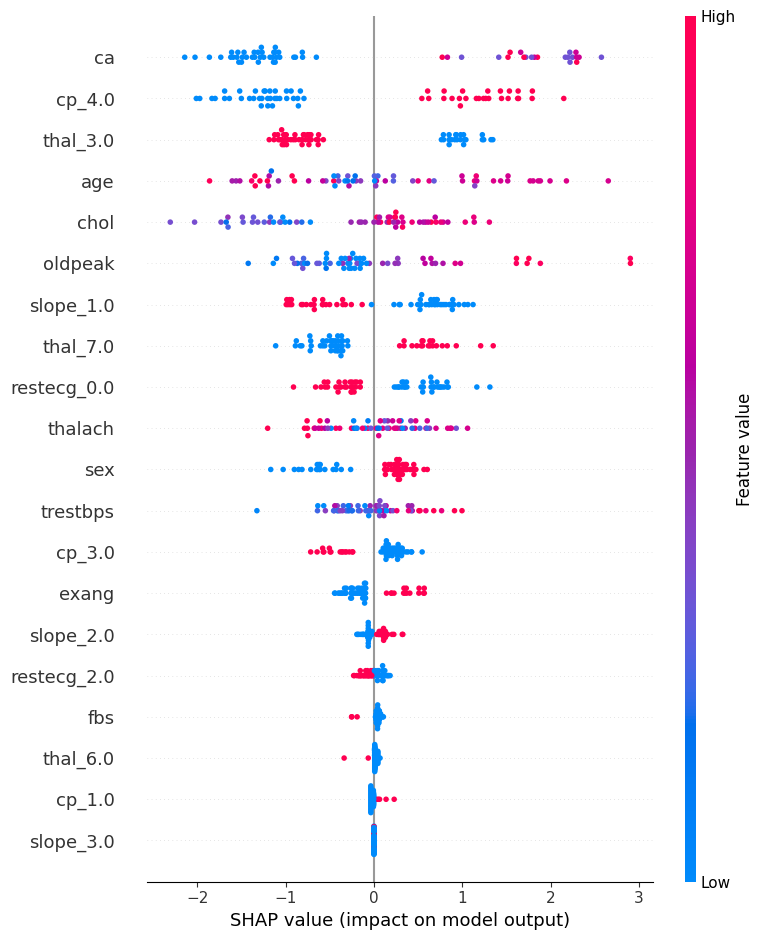

In [44]:
!pip install shap -q

import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_encoded)

shap.summary_plot(shap_values, X_test_encoded)

# PART B3 — Ensemble Comparison & ROC

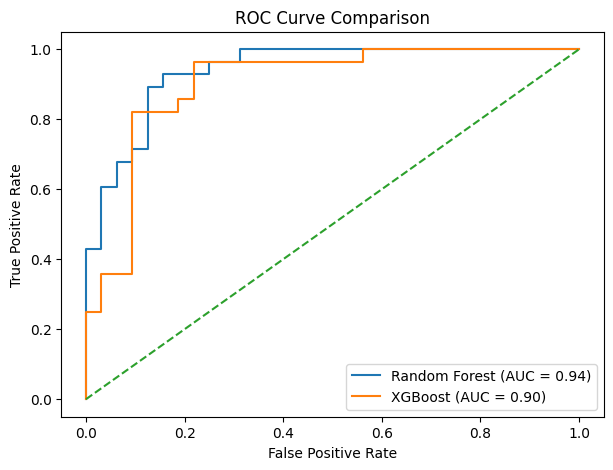

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Random Forest probabilities
rf_prob = best_rf.predict_proba(X_test_encoded)[:,1]

# XGBoost probabilities
xgb_prob = best_xgb.predict_proba(X_test_encoded)[:,1]

# ROC curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(7,5))

plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})')

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# PART C1 — Single-Layer Perceptron (SLP)

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train_encoded.shape[1],)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [47]:
history = model.fit(
    X_train_encoded, y_train,
    epochs=100,
    validation_data=(X_test_encoded, y_test),
    verbose=0
)

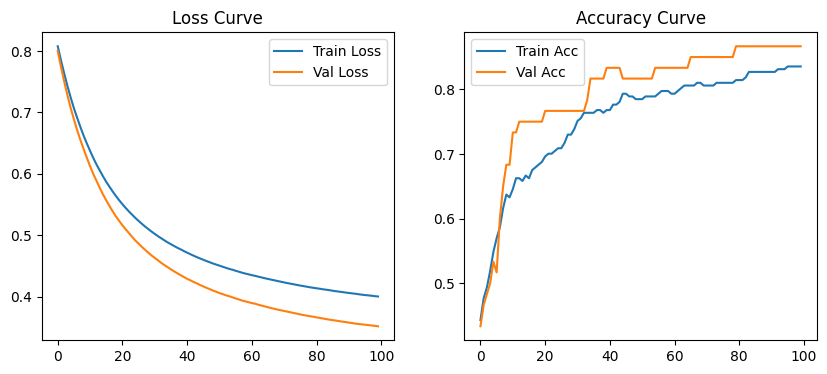

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_prob = model.predict(X_test_encoded).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60

AUC: 0.9386160714285714
[[29  3]
 [ 5 23]]


In [50]:
weights = model.layers[0].get_weights()[0]

weight_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'weight': weights.flatten()
})

weight_df['abs_weight'] = weight_df['weight'].abs()
weight_df = weight_df.sort_values(by='abs_weight', ascending=False)

print(weight_df.head(10))

        feature    weight  abs_weight
19     thal_3.0 -0.892374    0.892374
12       cp_4.0  0.524203    0.524203
14  restecg_1.0 -0.481298    0.481298
5       thalach -0.449653    0.449653
13  restecg_0.0 -0.399908    0.399908
6         exang  0.394961    0.394961
21     thal_7.0  0.378012    0.378012
8            ca  0.367847    0.367847
4           fbs  0.362633    0.362633
17    slope_2.0  0.351537    0.351537


# PART C2 — Multi-Layer Perceptron (MLP)

In [51]:
from tensorflow import keras
from tensorflow.keras import layers

def build_small():
    model = keras.Sequential([
        layers.Input(shape=(X_train_encoded.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [52]:
def build_medium():
    model = keras.Sequential([
        layers.Input(shape=(X_train_encoded.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [53]:
def build_large():
    model = keras.Sequential([
        layers.Input(shape=(X_train_encoded.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [54]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [55]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

def train_model(model):
    model = compile_model(model)
    history = model.fit(
        X_train_encoded, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )
    return model, history

In [56]:
small_model, small_hist = train_model(build_small())
medium_model, medium_hist = train_model(build_medium())
large_model, large_hist = train_model(build_large())

In [57]:
from sklearn.metrics import f1_score

def evaluate(model):
    y_prob = model.predict(X_test_encoded).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    return f1_score(y_test, y_pred)

print("Small F1:", evaluate(small_model))
print("Medium F1:", evaluate(medium_model))
print("Large F1:", evaluate(large_model))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Small F1: 0.8235294117647058


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Medium F1: 0.6190476190476191
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Large F1: 0.8518518518518519


In [58]:
best_mlp = medium_model  # change if needed

y_prob = best_mlp.predict(X_test_encoded).ravel()
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
              precision    recall  f1-score   support

           0       0.67      0.97      0.79        32
           1       0.93      0.46      0.62        28

    accuracy                           0.73        60
   macro avg       0.80      0.72      0.71        60
weighted avg       0.79      0.73      0.71        60

AUC: 0.8270089285714286
[[31  1]
 [15 13]]


# PART C3 — Ablation Study

In [59]:
def base_model():
    model = keras.Sequential([
        layers.Input(shape=(X_train_encoded.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [60]:
def variant_a():
    model = keras.Sequential([
        layers.Input(shape=(X_train_encoded.shape[1],)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [61]:
def variant_b():
    model = keras.Sequential([
        layers.Input(shape=(X_train_encoded.shape[1],)),
        layers.Dense(128, activation='sigmoid'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='sigmoid'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='sigmoid'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [62]:
def variant_c():
    model = base_model()
    return model

In [63]:
def train(model):
    model.fit(
        X_train_encoded, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        verbose=0
    )
    return model

In [64]:
from sklearn.metrics import f1_score

def evaluate(model):
    y_prob = model.predict(X_test_encoded).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    return f1_score(y_test, y_pred)

base = train(base_model())
a = train(variant_a())
b = train(variant_b())
c = train(variant_c())

print("Base F1:", evaluate(base))
print("No Dropout:", evaluate(a))
print("Sigmoid:", evaluate(b))
print("No Early Stop:", evaluate(c))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Base F1: 0.8
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
No Dropout: 0.7547169811320755
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Sigmoid: 0.8235294117647058
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
No Early Stop: 0.7547169811320755


# PART D1 — CNN on MNIST

In [65]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Use subset (as required)
X_train, y_train = X_train[:12000], y_train[:12000]
X_test, y_test = X_test[:2000], y_test[:2000]

print(X_train.shape, X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(12000, 28, 28) (2000, 28, 28)


In [66]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten for MLP baseline
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

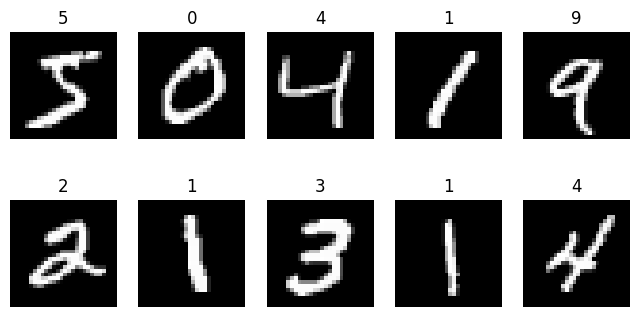

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')

plt.show()

In [68]:
from tensorflow import keras
from tensorflow.keras import layers

baseline = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = baseline.fit(
    X_train_flat, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8378 - loss: 0.6225 - val_accuracy: 0.9092 - val_loss: 0.3245
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9220 - loss: 0.2880 - val_accuracy: 0.9271 - val_loss: 0.2599
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9389 - loss: 0.2232 - val_accuracy: 0.9317 - val_loss: 0.2244
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9501 - loss: 0.1796 - val_accuracy: 0.9404 - val_loss: 0.2005
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9569 - loss: 0.1508 - val_accuracy: 0.9467 - val_loss: 0.1907


In [69]:
test_loss, test_acc = baseline.evaluate(X_test_flat, y_test)

print("Baseline MLP Accuracy:", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9185 - loss: 0.2752
Baseline MLP Accuracy: 0.9185000061988831


# PART D2 — Lightweight CNN

In [70]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train_cnn)

In [72]:
from tensorflow import keras
from tensorflow.keras import layers

cnn = keras.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [73]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [74]:
history = cnn.fit(
    datagen.flow(X_train_cnn, y_train, batch_size=32),
    validation_data=(X_test_cnn, y_test),
    epochs=5,
    verbose=1
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.6721 - loss: 0.9954 - val_accuracy: 0.9220 - val_loss: 0.2468
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8642 - loss: 0.4189 - val_accuracy: 0.9540 - val_loss: 0.1391
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9004 - loss: 0.3195 - val_accuracy: 0.9675 - val_loss: 0.1018
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9208 - loss: 0.2670 - val_accuracy: 0.9645 - val_loss: 0.0960
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9283 - loss: 0.2359 - val_accuracy: 0.9750 - val_loss: 0.0757


In [75]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = cnn.predict(X_test_cnn)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes))
print(confusion_matrix(y_test, y_pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       175
           1       1.00      0.99      0.99       234
           2       0.96      0.99      0.97       219
           3       0.96      1.00      0.98       207
           4       0.98      0.97      0.97       217
           5       0.98      0.98      0.98       179
           6       0.97      0.98      0.98       178
           7       0.98      0.96      0.97       205
           8       0.97      0.95      0.96       192
           9       0.96      0.94      0.95       194

    accuracy                           0.97      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.97      0.97      2000

[[173   0   0   0   1   0   1   0   0   0]
 [  0 231   1   0   0   0   2   0   0   0]
 [  0   0 216   0   0   0   0   3   0   0]
 [  0   0   0 206   0   0   0   1   0   0]
 [  0   0   0   0 211   0   1

# PART D3 — CNN Visualization

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Get first conv layer
filters, biases = cnn.layers[0].get_weights()

print("Filter shape:", filters.shape)

Filter shape: (3, 3, 1, 16)


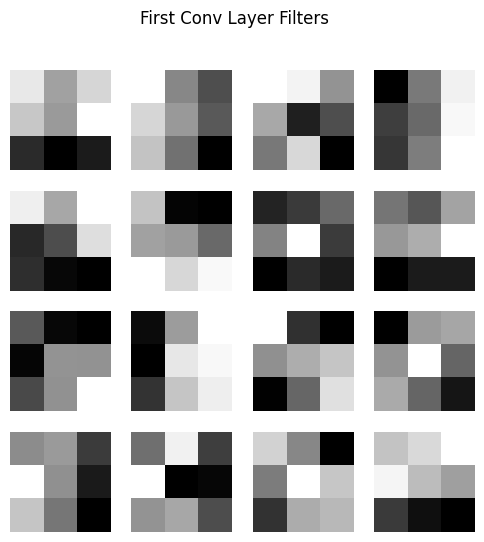

In [77]:
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    if i < 16:
        f = filters[:, :, 0, i]
        ax.imshow(f, cmap='gray')
        ax.axis('off')

plt.suptitle("First Conv Layer Filters")
plt.show()

In [79]:
cnn.build((None, 28, 28, 1))

In [81]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

inputs = Input(shape=(28,28,1))

x = Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D(2,2)(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(10, activation='softmax')(x)

cnn = Model(inputs, outputs)

In [82]:
layer_model = Model(inputs=cnn.input, outputs=cnn.layers[1].output)

In [103]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=cnn.input,
    outputs=cnn.get_layer("conv2d_2").output
)

In [104]:
img = X_test_cnn[0:1]
feature_maps = feature_extractor.predict(img)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
(1, 28, 28, 16)


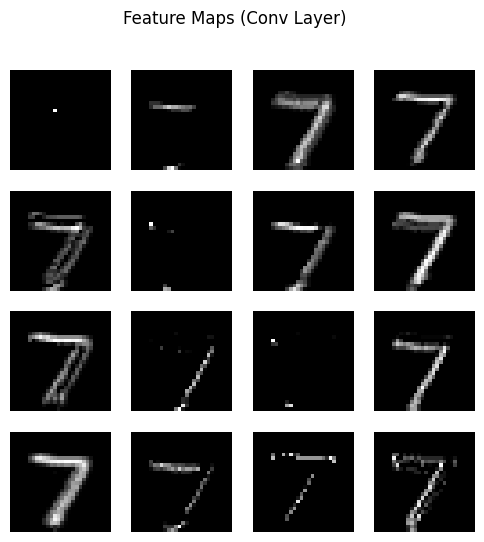

In [105]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, :, :, i], cmap='gray')
    ax.axis('off')

plt.suptitle("Feature Maps (Conv Layer)")
plt.show()

# PART E — Local Front-End Dashboard

In [108]:
best_rf = grid.best_estimator_

In [109]:
rf = RandomForestClassifier(...)

In [110]:
joblib.dump(rf, 'heart_model.pkl')

['heart_model.pkl']

In [113]:
print(dir())

['AgglomerativeClustering', 'Conv2D', 'Dense', 'Dropout', 'Flatten', 'GridSearchCV', 'ImageDataGenerator', 'In', 'Input', 'KMeans', 'MaxPooling2D', 'Model', 'Out', 'PCA', 'RandomForestClassifier', 'StandardScaler', 'TSNE', 'X', 'XGBClassifier', 'X_pca', 'X_test', 'X_test_cnn', 'X_test_encoded', 'X_test_flat', 'X_train', 'X_train_cnn', 'X_train_encoded', 'X_train_flat', 'X_tsne', '_', '_110', '_112', '_34', '_41', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_exit_code', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i108', '_i109', '_i11', '_i110', '_i111', '_i112', '_i113', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46'

In [114]:
import joblib

joblib.dump(best_rf, 'heart_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [115]:
joblib.dump(best_xgb, 'xgb_model.pkl')

['xgb_model.pkl']

In [116]:
import os
print(os.listdir())

['.config', 'processed.cleveland.data', 'xgb_model.pkl', 'scaler.pkl', 'heart_model.pkl', 'sample_data']


In [117]:
import joblib

model = joblib.load('heart_model.pkl')
scaler = joblib.load('scaler.pkl')

print("Model Loaded:", model)

Model Loaded: RandomForestClassifier(max_depth=5, n_estimators=200, oob_score=True,
                       random_state=42)


In [121]:
import pandas as pd
import numpy as np
import joblib

# Load
model = joblib.load('heart_model.pkl')
scaler = joblib.load('scaler.pkl')

# Column names
columns = [
    'age','sex','cp','trestbps','chol','fbs',
    'restecg','thalach','exang','oldpeak',
    'slope','ca','thal'
]

# Raw input
sample = pd.DataFrame([[63,1,1,145,233,1,2,150,0,2.3,3,0,6]], columns=columns)

# One-hot encode
sample_encoded = pd.get_dummies(sample)

# 🔥 CRITICAL: Align with training columns
sample_encoded = sample_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Scale continuous columns
continuous_cols = ['age','trestbps','chol','thalach','oldpeak','ca']
sample_encoded[continuous_cols] = scaler.transform(sample_encoded[continuous_cols])

# Predict
pred = model.predict(sample_encoded)
prob = model.predict_proba(sample_encoded)

print("Prediction:", pred)
print("Probability:", prob)

Prediction: [0]
Probability: [[0.63785776 0.36214224]]
